<a href="https://colab.research.google.com/github/anchalsinha-0411/Detection-of-a-Fraud.CSV-file/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection in Financial Transactions

### Business Case Study

This project focuses on building a machine learning model to proactively
detect fraudulent financial transactions and provide actionable business insights.


## Problem Statement

Financial fraud causes significant financial losses and impacts customer trust.
The objective of this project is to analyze transaction data, build a fraud
detection model, and suggest preventive measures based on model insights.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = pd.read_csv('/content/drive/MyDrive/DATA SET/Fraud.csv')

In [10]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [11]:
df.shape

(1536598, 11)

In [13]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536598e+06,1.536597e+06,1536597.0
mean,6.132086e+01,1.610345e+05,8.700393e+05,8.908140e+05,9.891209e+05,1.114045e+06,1.138880e-03,0.0
std,5.220271e+01,2.695586e+05,2.959877e+06,2.996250e+06,2.302070e+06,2.406165e+06,3.372809e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.700000e+01,1.289010e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.900000e+01,7.750487e+04,1.532400e+04,0.000000e+00,1.322262e+05,2.225372e+05,0.000000e+00,0.0
75%,1.310000e+02,2.160513e+05,1.254459e+05,1.663345e+05,9.359249e+05,1.151265e+06,0.000000e+00,0.0
max,1.540000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536598 entries, 0 to 1536597
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1536598 non-null  int64  
 1   type            1536598 non-null  object 
 2   amount          1536598 non-null  float64
 3   nameOrig        1536598 non-null  object 
 4   oldbalanceOrg   1536598 non-null  float64
 5   newbalanceOrig  1536598 non-null  float64
 6   nameDest        1536598 non-null  object 
 7   oldbalanceDest  1536598 non-null  float64
 8   newbalanceDest  1536598 non-null  float64
 9   isFraud         1536597 non-null  float64
 10  isFlaggedFraud  1536597 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 129.0+ MB


## Data Overview

The dataset contains approximately 6.3 million transaction records and 10 features.
It includes transaction type, amount, account balances, and fraud labels.

In [16]:
# 4. Data Cleaning
df.isnull().sum() ### Missing Values


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,1


### Outliers and Multicollinearity

Fraudulent transactions naturally contain unusually high transaction amounts.
Correlation was observed among balance-related features; however, tree-based
models such as Random Forest are robust to multicollinearity.


## Fraud Detection Model Description

A Random Forest classifier was selected because it can capture complex
non-linear relationships, handle imbalanced data, and provide feature
importance for model interpretability.


In [19]:
# 6. Feature Engineering and Selection
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

df['orig_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1, errors='ignore')

In [20]:
print("Shape after feature engineering:")
df.shape

Shape after feature engineering:


(1536598, 10)

In [21]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_change,dest_balance_change
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,-21182.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [24]:
# 7. Train-Test Split
# Drop rows where 'isFraud' is NaN
df_cleaned = df.dropna(subset=['isFraud'])

# Convert 'isFraud' to integer type
df_cleaned['isFraud'] = df_cleaned['isFraud'].astype(int)

X = df_cleaned.drop('isFraud', axis=1)
y = df_cleaned['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("training samples:",X_train.shape[0])
print("testing samples:", X_test.shape[0])
print("Fraud ratio in train set:\n",y_train.value_counts(normalize=True))

/tmp/ipython-input-2972114041.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['isFraud'] = df_cleaned['isFraud'].astype(int)


training samples: 1229277
testing samples: 307320
Fraud ratio in train set:
 isFraud
0    0.998861
1    0.001139
Name: proportion, dtype: float64


## Model Performance Evaluation

Due to the highly imbalanced nature of fraud data, performance was evaluated
using precision, recall, F1-score, and ROC-AUC instead of accuracy.


In [26]:
# 8. Model Training
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


## Model Performance Evaluation

Due to the highly imbalanced nature of fraud data, performance was evaluated
using precision, recall, F1-score, and ROC-AUC instead of accuracy.


In [27]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    306970
           1       1.00      0.79      0.88       350

    accuracy                           1.00    307320
   macro avg       1.00      0.89      0.94    307320
weighted avg       1.00      1.00      1.00    307320



In [28]:
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print(roc_auc_score)

<function roc_auc_score at 0x782f955c11c0>


In [29]:
# Key Factors Predicting Fraud
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

,0
orig_balance_change,0.372519
oldbalanceOrg,0.154170
newbalanceOrig,0.141883
amount,0.125409
type,0.065823
dest_balance_change,0.058689
step,0.033163
newbalanceDest,0.032686
oldbalanceDest,0.015658


In [30]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:\n")
print(importances.head(10))

Top 10 Important Features:

orig_balance_change    0.372519
oldbalanceOrg          0.154170
newbalanceOrig         0.141883
amount                 0.125409
type                   0.065823
dest_balance_change    0.058689
step                   0.033163
newbalanceDest         0.032686
oldbalanceDest         0.015658
dtype: float64


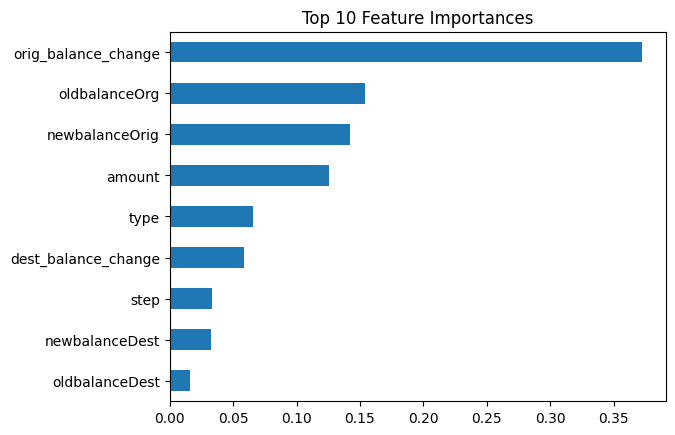

In [31]:
import matplotlib.pyplot as plt

importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()